# **Data/**

In [57]:
!pip install obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime


In [58]:
client = Client("USGS")
catalog=client.get_events(starttime=UTCDateTime("2016-05-30"),endtime=UTCDateTime("2026-05-30"),minmagnitude=4,minlatitude=6,maxlatitude=15,minlongitude=90,maxlongitude=98)
print(catalog)
print("number of events:",len(catalog))

925 Event(s) in Catalog:
2026-05-17T09:38:20.685000Z | +11.049,  +95.111 | 4.6  mb | manual
2026-05-16T21:16:16.654000Z | +13.017,  +93.702 | 4.7  mb | manual
...
2016-07-13T17:56:32.830000Z | +12.082,  +95.170 | 4.5  mb | manual
2016-06-13T00:16:58.710000Z |  +6.384,  +94.355 | 4.2  mb | manual
To see all events call 'print(CatalogObject.__str__(print_all=True))'
number of events: 925


In [59]:
import pandas as pd
rows=[]
for event in catalog:
 origin=event.origins[0]
 mag=event.magnitudes[0]

 rows.append({"time":origin.time.datetime,"latitude":origin.latitude,"longitude":origin.longitude,"depth_km":origin.depth/1000,"magnitude":mag.mag})
df=pd.DataFrame(rows)
print(df.head(10))

                     time  latitude  longitude  depth_km  magnitude
0 2026-05-17 09:38:20.685   11.0493    95.1108    10.000        4.6
1 2026-05-16 21:16:16.654   13.0167    93.7021    96.882        4.7
2 2026-05-12 05:18:57.354    6.9852    92.3567    10.000        4.9
3 2026-05-08 03:53:33.205   10.1728    91.4911    10.000        4.6
4 2026-05-03 10:33:34.042    8.1018    91.9353    10.000        4.2
5 2026-05-01 03:12:50.564    8.0760    91.8795    10.000        4.8
6 2026-04-10 03:36:01.376    9.0424    94.0030    10.000        4.3
7 2026-04-08 22:13:51.268   10.4649    93.7220    10.000        4.6
8 2026-04-05 00:09:30.549    6.3939    92.4656    10.000        4.5
9 2026-04-05 00:05:48.007    6.2934    92.4536    10.000        4.0


In [60]:
df.to_csv("USGS andaman_nicobar_M4_catalog.csv", index=False)

print("CSV saved successfully")

CSV saved successfully


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path("/content/USGS andaman_nicobar_M4_catalog (1).csv"))

df.head()

,time,latitude,longitude,depth_km,magnitude
0,2026-05-17 09:38:20.685,11.0493,95.1108,10.000,4.6
1,2026-05-16 21:16:16.654,13.0167,93.7021,96.882,4.7
2,2026-05-12 05:18:57.354,6.9852,92.3567,10.000,4.9
3,2026-05-08 03:53:33.205,10.1728,91.4911,10.000,4.6
4,2026-05-03 10:33:34.042,8.1018,91.9353,10.000,4.2


# **3.notebooks/03_baseline_forecast**

In [62]:
!pip install pmdarima

In [63]:
#creating monthly counts
df['time'] = pd.to_datetime(df['time'])
monthly_counts = df.set_index('time').resample('MS').size()
monthly_counts.head()

,0
time,
2016-06-01,1
2016-07-01,3
2016-08-01,7
2016-09-01,11
2016-10-01,2


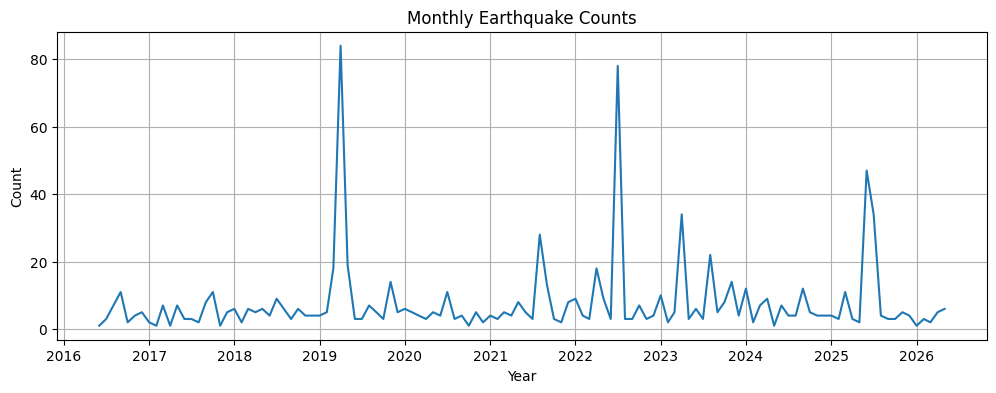

In [64]:
#plotting monthly counts
plt.figure(figsize=(12,4))

plt.plot(monthly_counts.index,
         monthly_counts.values)

plt.title("Monthly Earthquake Counts")
plt.ylabel("Count")
plt.xlabel("Year")

plt.grid(True)
plt.show()

## **(a)Train on 80%,forecast remaining 20%**

In [65]:
#Train-Test split(80%-20%)
split_idx = int(len(monthly_counts)*0.8)

train = monthly_counts.iloc[:split_idx]
test  = monthly_counts.iloc[split_idx:]

print("Training observations :", len(train))
print("Testing observations  :", len(test))

Training observations : 96
Testing observations  : 24


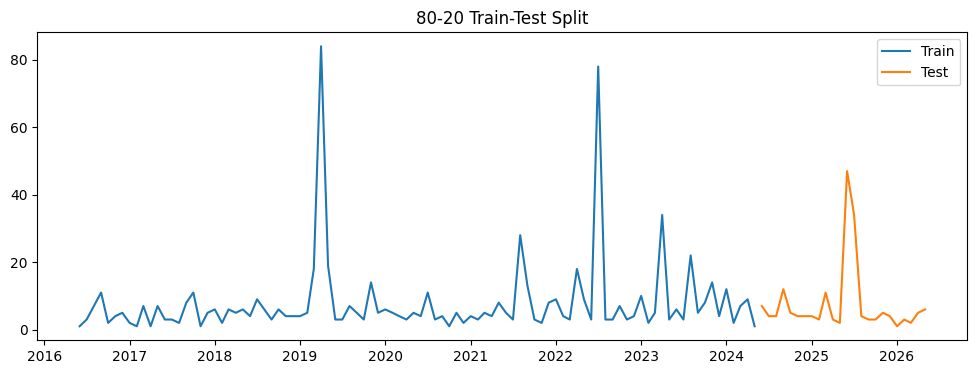

In [66]:
plt.figure(figsize=(12,4))

plt.plot(train,label="Train")
plt.plot(test,label="Test")

plt.legend()
plt.title("80-20 Train-Test Split")
plt.show()

In [67]:
#check stationary (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

ADF Statistic : -8.967327149842728
p-value       : 7.924155768248149e-15


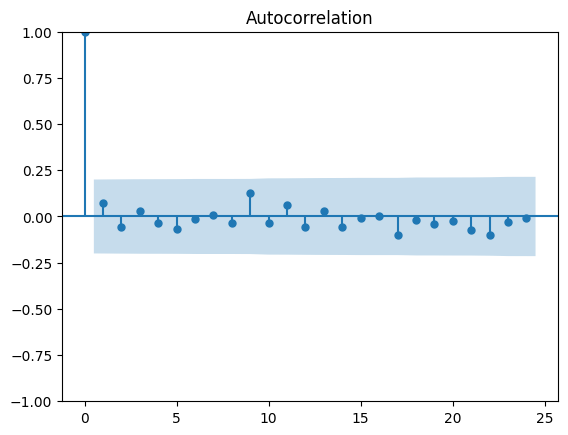

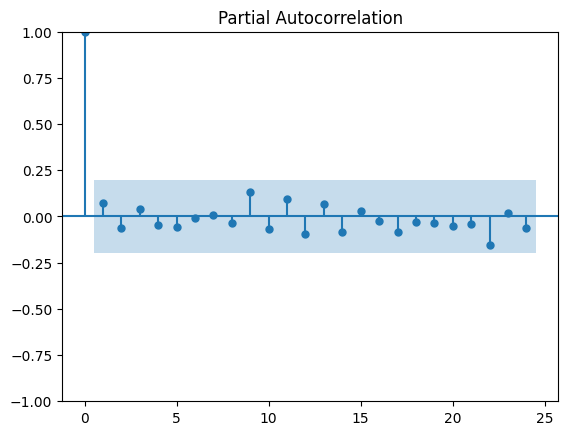

In [68]:
#ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train,lags=24)
plt.show()

plot_pacf(train,lags=24)
plt.show()

## **(b)fit ARIMA on monthly counts**

In [69]:
#fit ARIMA
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,1))

fit = model.fit()

print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -372.453
Date:                Fri, 05 Jun 2026   AIC                            752.907
Time:                        10:17:34   BIC                            763.164
Sample:                    06-01-2016   HQIC                           757.053
                         - 05-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.7612      3.357      2.312      0.021       1.181      14.342
ar.L1         -0.8743      0.138     -6.331      0.000      -1.145      -0.604
ma.L1          0.9998      7.224      0.138      0.8

## **(c)Log-Likelihood score**

In [70]:
#Log-Likelihood
print("Log-Likelihood =", fit.llf)

Log-Likelihood = -372.453309642538


## **(d)Forecast Remaining**

In [71]:
#forecast test period
forecast = fit.forecast(steps=len(test))
forecast.index = test.index
forecast.head()

,predicted_mean
time,
2024-06-01,8.546300
2024-07-01,7.074697
2024-08-01,8.361369
2024-09-01,7.236388
2024-10-01,8.219997


## **(e)Report RMSE and MAE**

In [72]:
#RMSE and MAE
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(test,forecast)
rmse = np.sqrt(mean_squared_error(test,forecast))

print("MAE  =", mae)
print("RMSE =", rmse)

MAE  = 6.41916334194972
RMSE = 10.436408496716428


## **(F)Compare to a naive "last-year-mean"baseline**

In [73]:
#building naive last-year-mean baseline
baseline_mean = train.iloc[-12:].mean()

baseline_forecast = pd.Series(baseline_mean,index=test.index)
baseline_forecast.head()

,0
time,
2024-06-01,7.75
2024-07-01,7.75
2024-08-01,7.75
2024-09-01,7.75
2024-10-01,7.75


In [74]:
baseline_mae = mean_absolute_error(test,baseline_forecast)
baseline_rmse = np.sqrt(mean_squared_error(test,baseline_forecast))

print("Baseline MAE  =", baseline_mae)
print("Baseline RMSE =", baseline_rmse)

Baseline MAE  = 6.333333333333333
Baseline RMSE = 10.423331201364242


In [75]:
comparison = pd.DataFrame({"Model":["ARIMA","Last-Year-Mean"],"MAE":[mae,baseline_mae],
  "RMSE":[rmse, baseline_rmse]})

comparison

,Model,MAE,RMSE
0,ARIMA,6.419163,10.436408
1,Last-Year-Mean,6.333333,10.423331


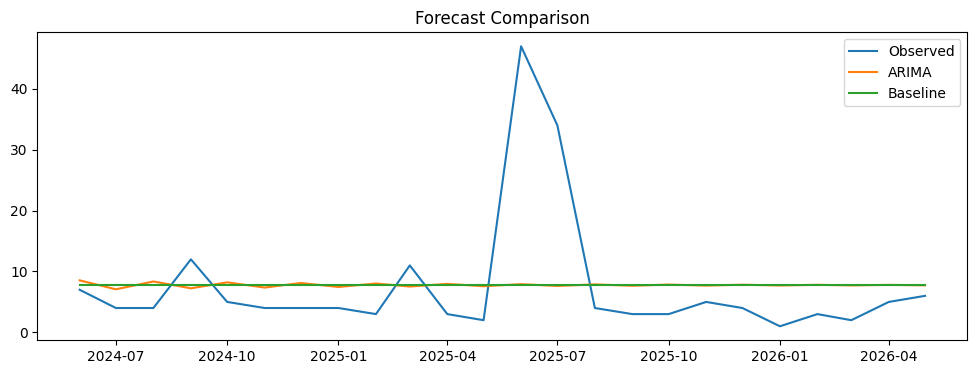

In [76]:
plt.figure(figsize=(12,4))

plt.plot(test,label="Observed")
plt.plot(forecast,label="ARIMA")
plt.plot(baseline_forecast,label="Baseline")
plt.legend()
plt.title("Forecast Comparison")
plt.show()

# **5.src/eq_pipeline**

In [77]:
!mkdir -p src/eq_pipeline

In [78]:
%%writefile src/eq_pipeline/__init__.py
from .ingest import load_catalog
from .stats import calculate_b_value
from .forecast import forecast_rate

Overwriting src/eq_pipeline/__init__.py


In [79]:
%%writefile src/eq_pipeline/ingest.py
import pandas as pd

def load_catalog(file_path: str):
    return pd.read_csv(file_path)

Overwriting src/eq_pipeline/ingest.py


In [80]:
%%writefile src/eq_pipeline/stats.py

import numpy as np

def calculate_b_value(magnitudes, mc, dM=0.1):

    mean_mag = np.mean(magnitudes)

    b = 1 / (np.log(10) *(mean_mag - mc + dM/2))
    return b

def bootstrap_b_value(magnitudes, mc,dM=0.1,n_boot=1000):

    boot_b = []

    for _ in range(n_boot):

        sample = np.random.choice(magnitudes,size=len(magnitudes),replace=True)
        mean_sample = np.mean(sample)

        b_sample = 1 / (np.log(10) *(mean_sample - mc + dM/2))

        boot_b.append(b_sample)

    ci_low = np.percentile(boot_b, 2.5)
    ci_high = np.percentile(boot_b, 97.5)

    return ci_low, ci_high

Overwriting src/eq_pipeline/stats.py


In [81]:
%%writefile src/eq_pipeline/forecast.py

from statsmodels.tsa.arima.model import ARIMA

def forecast_rate(train, steps, order=(1,1,1)):

    model = ARIMA(train, order=order)

    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=steps)

    return fitted_model, forecast

Overwriting src/eq_pipeline/forecast.py


In [82]:
import sys
sys.path.append("src")

In [83]:
import importlib
import eq_pipeline.ingest
importlib.reload(eq_pipeline.ingest)

from eq_pipeline.ingest import load_catalog
from eq_pipeline.stats import calculate_b_value
from eq_pipeline.forecast import forecast_rate

In [84]:
from google.colab import files
uploaded = files.upload()

Saving USGS andaman_nicobar_M4_catalog.csv to USGS andaman_nicobar_M4_catalog (2).csv


In [85]:
data = pd.read_csv(Path("/content/USGS andaman_nicobar_M4_catalog.csv"))

**adding docstrings and type hints**

**(a)ingest.py**

In [86]:
import pandas as pd

def load_catalog(file_path: str) -> pd.DataFrame:
    """
    Load earthquake catalog from a JSON file.

    Parameters
    ----------
    file_path : str
        Path to the JSON file.

    Returns
    -------
    pd.DataFrame
        Data loaded into a pandas DataFrame.
    """
    return pd.read_json(file_path)

**(b)stats.py**

In [87]:
import numpy as np

def calculate_b_value(magnitudes: np.ndarray, mc: float) -> float:
    """
    Calculate Gutenberg-Richter b-value.

    Parameters
    ----------
    magnitudes : np.ndarray
        Array of earthquake magnitudes.
    mc : float
        Magnitude of completeness.

    Returns
    -------
    float
        Estimated b-value.
    """
    mean_mag = np.mean(magnitudes[magnitudes >= mc])
    return np.log10(np.exp(1)) / (mean_mag - mc)

**(c)forecast.py**

In [88]:
import pandas as pd

def forecast_rate(data: pd.DataFrame) -> float:
    """
    Estimate earthquake occurrence rate.

    Parameters
    ----------
    data : pd.DataFrame
        Earthquake catalog.

    Returns
    -------
    float
        Estimated daily event rate.
    """
    return len(data) / 365

In [89]:
%%writefile src/eq_pipeline/__init__.py
"""
Earthquake forecasting pipeline package.

This package contains modules for data ingestion,
statistical analysis, and forecasting.
"""

from .ingest import load_catalog
from .stats import calculate_b_value
from .forecast import forecast_rate

Overwriting src/eq_pipeline/__init__.py


# **6.README.md**

In [90]:
%%writefile README.md
# Earthquake Forecasting Project

This project analyzes earthquake catalog data and computes b-value and Mc.

## How to Reproduce

1. Create environment:

conda env create -f environment.yml

2. Activate environment:

conda activate earthquake_env

3. Start Jupyter:

jupyter lab

4. Run the notebook.

## Figures

- Figure 1: Magnitude Distribution
- Figure 2: ACF Plot
- Figure 3: PACF Plot


Overwriting README.md


In [91]:
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

In [92]:
import matplotlib.pyplot as plt
plt.savefig("figures/magnitude_distribution.png")
plt.savefig("figures/acf.png")
plt.savefig("figures/Pacf.png")

<Figure size 640x480 with 0 Axes>

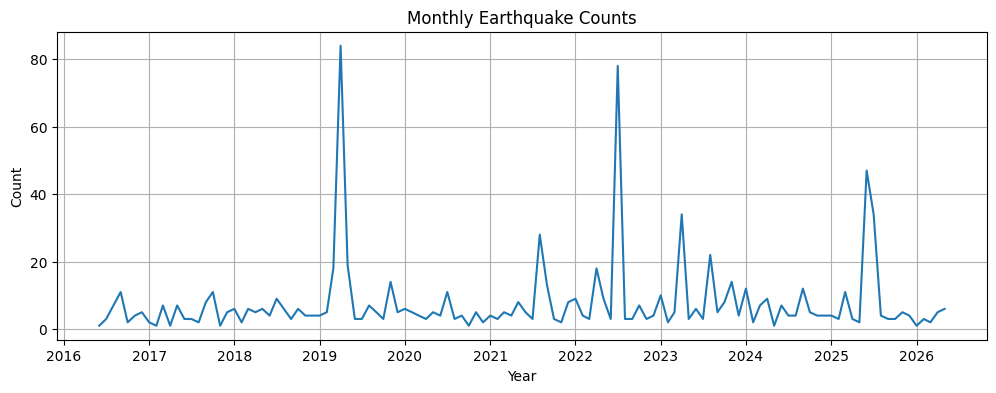

In [93]:
#magnitude-distribution
plt.figure(figsize=(12,4))

plt.plot(monthly_counts.index,
         monthly_counts.values)

plt.title("Monthly Earthquake Counts")
plt.ylabel("Count")
plt.xlabel("Year")

plt.grid(True)
fig.savefig("figures/magnitude_distribution.png")
plt.show()

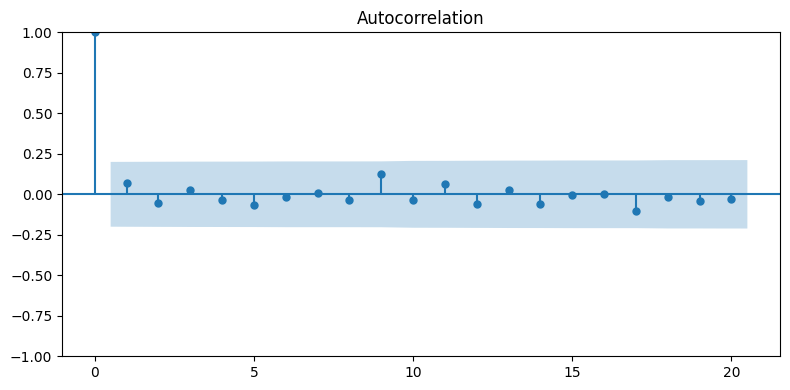

In [94]:
#ACF plot
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
plot_acf(train, ax=ax)

plt.tight_layout()
fig.savefig("figures/acf.png")

plt.show()

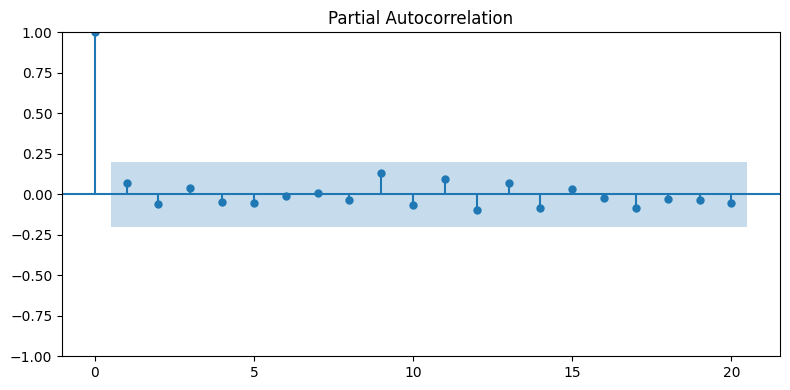

In [95]:
#PACF Plot
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
plot_pacf(train, ax=ax)

plt.tight_layout()
fig.savefig("figures/pacf.png")

plt.show()

# **7.enviroment.yml**

In [96]:
%%writefile environment.yml
name: earthquake_env

channels:
  - conda-forge

dependencies:
  - python=3.11
  - numpy
  - pandas
  - scipy
  - matplotlib
  - scikit-learn
  - statsmodels
  - pmdarima
  - obspy
  - cartopy

Overwriting environment.yml
